In [2]:
import pyflubl 
import pybdsim

Al_100cm = pyflubl.Analysis.PyflublOutput(jsonFileName="./Al_100cm/pyflubl.json",
                                          jsonCoordinateFileName="./Al_100cm/T300_FLUKA_target_ALUMINUM_1.0_coordinates.json",
                                          rootFileName="./Al_100cm/T300_FLUKA_target_ALUMINUM_1.0001_pyflubl.root",
                                          dumpFileName="./Al_100cm/T300_FLUKA_target_ALUMINUM_1.0001_dump",
                                          usrbinFileName=None)
Al_100cm_BDSIM = pybdsim.DataPandas.Load("./Al_100cm/T300_BDSIM_target_G4_Al_1.0.root")
Al_100cm_BDSIM_el = Al_100cm_BDSIM.get_eloss()

initializing ocelot...


<Axes: xlabel='z/mm', ylabel='x/mm'>

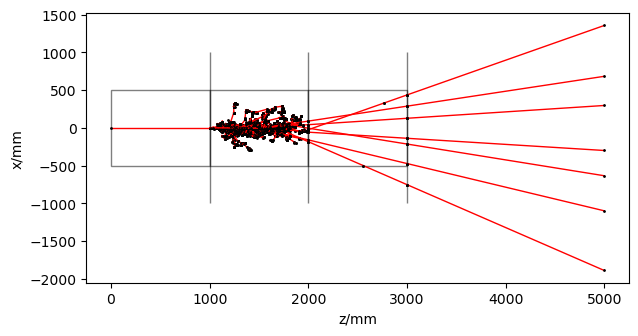

In [4]:
Al_100cm.plot_projection()

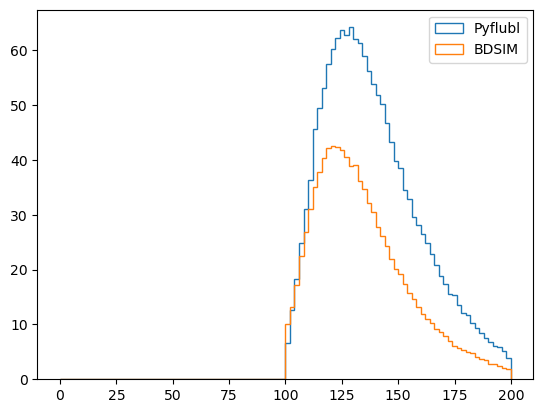

In [5]:
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
Eloss_E = np.array(ak.flatten(Al_100cm.uprootTree['eloss.E'].array(library="ak")))
Eloss_S = np.array(ak.flatten(Al_100cm.uprootTree['eloss.S'].array(library="ak")))
plt.hist(Eloss_S, 100, (0,200), weights=Eloss_E, histtype="step", label="Pyflubl");
plt.hist(Al_100cm_BDSIM_el['S']*100, 100,(0,200), weights=Al_100cm_BDSIM_el['energy'], histtype="step", label="BDSIM");
plt.legend()